# Evaluation Analysis

Loads pre-computed results from the current pipeline: `evaluation/eval_utility.py`
(TSTR/TRTR/retention) and `evaluation/eval_fidelity.py` (SDMetrics), both as
mean ± std over `seeds.RUN_SEEDS`, plus `results/computational_cost.csv`.

Does **not** recompute anything — run those scripts first.

**Privacy cells below are LEGACY** (iteration 1/2, `results/tapas_LEGACY/`) and are not
going into the write-up. The current privacy results live in `benchmark_tapas/`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

RESULTS = Path('../results')


# Repo palette (from the reference chart): orange + grey primary, teal + pink accent.
ORANGE, GREY, TEAL, PINK = "#CE4E36", "#3A3A3A", "#8CA9A0", "#D2B4B1"
# 5th slot for AIM - the 4-colour palette had no free step. Slate blue is separable
# from all four and is not the limiting pair (see palette note below).
SLATE = "#6B7F99"

METHOD_ORDER  = ['bayesian_network', 'privbayes', 'ctgan', 'dpgan', 'aim']
METHOD_LABELS = {
    'bayesian_network': 'BN',
    'privbayes':        'PrivBayes',
    'ctgan':            'CTGAN',
    'dpgan':            'DPGAN',
    'aim':              'AIM',
}
COLORS = {
    'bayesian_network': ORANGE,
    'privbayes':        GREY,
    'ctgan':            TEAL,
    'dpgan':            PINK,
    'aim':              SLATE,
}

# TAPAS has only been run for the original four generators, so the privacy plots use
# this order instead. Do NOT use METHOD_ORDER there: AIM's privacy cells are NaN, and
# the eff-epsilon cell maps non-finite values to INF_CAP - which would draw AIM as
# maximally leaking rather than as 'not yet measured'.
PRIVACY_ORDER = ['bayesian_network', 'privbayes', 'ctgan', 'dpgan']

# Palette note: CTGAN (teal) vs DPGAN (pink) separate by only dE 10.8 in normal vision
# and 5.9 under protanopia, below the dE 15 / 8 floors. Every chart below also labels
# methods on the x-axis or directly, so identity is never colour-alone - that is the
# required relief. Worth re-stepping if these ever appear without labels.

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


## Load results

In [2]:
# Utility + fidelity now come from the in-house multi-run tables (mean +/- std over
# seeds.RUN_SEEDS), not synthcity. results/synthcity_results.csv has been DELETED:
# its TSTR was scored on an internal split of the generators' own training data,
# so memorisation was rewarded. See evaluation/eval_utility.py for the replacement.
util_raw = pd.read_csv(RESULTS / 'utility_summary.csv')     # <- evaluation/eval_utility.py
fid_raw  = pd.read_csv(RESULTS / 'fidelity_summary.csv')    # <- evaluation/eval_fidelity.py

# TAPAS below is iteration 1 (LEGACY), kept only so the older privacy plots still run.
# The correct privacy results live in benchmark_tapas/ and are NOT loaded here.
tap = pd.read_csv(RESULTS / 'tapas_LEGACY' / 'tapas_results.csv')

print('Utility (in-house):  ', util_raw.shape)
print('Fidelity (in-house): ', fid_raw.shape)
print('TAPAS (LEGACY iter 1):', tap.shape)



Utility (in-house):   (5, 14)
Fidelity (in-house):  (5, 10)
TAPAS (LEGACY iter 1): (4, 13)


In [3]:
# LEGACY (iteration 2): effective epsilon for PrivBayes only. Superseded by
# benchmark_tapas/ -- kept so the earlier numbers stay reachable.
effeps_privbayes = pd.read_csv(RESULTS / 'tapas_LEGACY' / 'tapas_results' /
                               'eff_eps_results' / 'privbayes' / 'effeps_privbayes.csv')
effeps_privbayes[["attack", "eps_low_90", "eps_high_90",
                  "eps_low_95", "eps_high_95", "eps_low_99", "eps_high_99"]]



,attack,eps_low_90,eps_high_90,eps_low_95,eps_high_95,eps_low_99,eps_high_99
0,Groundhog,2.390153,inf,2.209964,inf,1.878477,inf
1,ShadowModelling(RandomQueries),2.390153,inf,2.209964,inf,1.878477,inf
2,"LocalNeighbourhood(L_2, 0.250411558405805, acc...",0.000000,0.085788,0.000000,0.101908,0.000000,0.139336
3,ProbabilityEstimation(KernelDensity()),0.000000,0.085788,0.000000,0.101908,0.000000,0.139336


In [4]:
# Both summary tables are wide already: one row per method, a _mean and a _std per
# metric. Split each into a mean frame and a std frame, indexed by method label.
FIDELITY_STEMS = ['KSComplement', 'TVComplement',
                  'CorrelationSimilarity', 'ContingencySimilarity']
UTILITY_STEMS  = ['tstr_xgboost_auc', 'trtr_xgboost_auc', 'retention_xgboost',
                  'tstr_logistic_regression_auc', 'trtr_logistic_regression_auc',
                  'retention_logistic_regression']

def mean_std(raw, stems):
    d = raw.set_index('method').reindex(METHOD_ORDER)
    d.index = [METHOD_LABELS[m] for m in d.index]
    mean = pd.DataFrame({s: d[f'{s}_mean'] for s in stems if f'{s}_mean' in d}, index=d.index)
    sd   = pd.DataFrame({s: d[f'{s}_std']  for s in stems if f'{s}_std'  in d}, index=d.index)
    return mean, sd

# `sdm` keeps its old name so the fidelity cells below are unchanged; its columns are
# now run means rather than a single draw.
sdm, sdm_sd = mean_std(fid_raw, FIDELITY_STEMS)
util, util_sd = mean_std(util_raw, UTILITY_STEMS)
print('n runs per method:', util_raw.set_index('method')['n_runs'].to_dict())



n runs per method: {'bayesian_network': 5, 'privbayes': 5, 'ctgan': 5, 'dpgan': 5, 'aim': 5}


In [5]:
# Utility, mean over runs. TSTR/TRTR are both AUC on the SAME 5,381-record holdout.
util.round(4)



,tstr_xgboost_auc,trtr_xgboost_auc,retention_xgboost,tstr_logistic_regression_auc,trtr_logistic_regression_auc,retention_logistic_regression
BN,0.7594,0.9274,0.8188,0.7561,0.902,0.8383
PrivBayes,0.8534,0.9274,0.9202,0.8379,0.902,0.9289
CTGAN,0.8626,0.9274,0.9301,0.8714,0.902,0.9660
DPGAN,0.5087,0.9274,0.5485,0.5585,0.902,0.6192
AIM,0.6783,0.9274,0.7314,0.7324,0.902,0.8120


In [6]:
# Fidelity, mean over runs (synthetic vs training data).
sdm.round(4)



,KSComplement,TVComplement,CorrelationSimilarity,ContingencySimilarity
BN,0.7274,0.8966,0.9702,0.7889
PrivBayes,0.8524,0.9445,0.9602,0.8911
CTGAN,0.6638,0.8713,0.9846,0.7717
DPGAN,0.2888,0.2480,0.9566,0.0864
AIM,0.9121,0.9876,0.8018,0.9402


In [7]:
# TAPAS — already wide
tap = tap.set_index('method').reindex(METHOD_ORDER)
tap.index = [METHOD_LABELS[m] for m in tap.index]
tap


,mia_auc,mia_advantage,mia_privacy_gain,mia_eff_epsilon,mia_tp,mia_fp,aia_auc,aia_advantage,aia_privacy_gain,aia_eff_epsilon,eps_low_90,eps_high_90
BN,0.514911,0.046667,0.953333,1.203973,0.523333,0.476667,0.755543,0.207067,0.792933,3.799172,0.0,0.030240
PrivBayes,0.498189,-0.006667,1.006667,0.302281,0.496667,0.503333,0.834531,0.306658,0.693342,inf,0.0,0.018037
CTGAN,0.461489,-0.073333,1.073333,0.980829,0.463333,0.536667,0.874886,0.444876,0.555124,inf,0.0,0.013562
DPGAN,0.506633,0.040000,0.960000,0.788457,0.520000,0.480000,0.730269,0.024264,0.975736,inf,0.0,0.037938
AIM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Utility retention = TSTR / TRTR, both scored on the same 5,381-record holdout,
# so this is a like-for-like ratio. Computed in eval_utility.py; read back here
# with its across-run spread.
ret = pd.DataFrame({
    'retention_xgb':    util['retention_xgboost'],
    'retention_xgb_sd': util_sd['retention_xgboost'],
    'retention_lr':     util['retention_logistic_regression'],
    'retention_lr_sd':  util_sd['retention_logistic_regression'],
})
ret.round(4)



,retention_xgb,retention_xgb_sd,retention_lr,retention_lr_sd
BN,0.8188,0.0111,0.8383,0.0346
PrivBayes,0.9202,0.0540,0.9289,0.0496
CTGAN,0.9301,0.0057,0.9660,0.0046
DPGAN,0.5485,0.0993,0.6192,0.2112
AIM,0.7314,0.0213,0.8120,0.0511


## Master comparison table

In [9]:
# Pull key metrics from each source
key_utility  = ['BinaryLogisticRegression_F1', 'LogisticDetection']
key_fidelity = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
key_privacy  = ['DCRBaselineProtection', 'NewRowSynthesis',
                'mia_auc', 'mia_advantage', 'mia_eff_epsilon',
                'aia_auc', 'aia_eff_epsilon', 'eps_low_90', 'eps_high_90']

master = pd.concat([
    sdm[key_fidelity],
    sdm[[c for c in key_utility if c in sdm.columns]],
    tap[[c for c in key_privacy if c in tap.columns]],
], axis=1)

master.round(4)


,KSComplement,TVComplement,CorrelationSimilarity,ContingencySimilarity,mia_auc,mia_advantage,mia_eff_epsilon,aia_auc,aia_eff_epsilon,eps_low_90,eps_high_90
BN,0.7274,0.8966,0.9702,0.7889,0.5149,0.0467,1.2040,0.7555,3.7992,0.0,0.0302
PrivBayes,0.8524,0.9445,0.9602,0.8911,0.4982,-0.0067,0.3023,0.8345,inf,0.0,0.0180
CTGAN,0.6638,0.8713,0.9846,0.7717,0.4615,-0.0733,0.9808,0.8749,inf,0.0,0.0136
DPGAN,0.2888,0.2480,0.9566,0.0864,0.5066,0.0400,0.7885,0.7303,inf,0.0,0.0379
AIM,0.9121,0.9876,0.8018,0.9402,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot 1 — Fidelity comparison

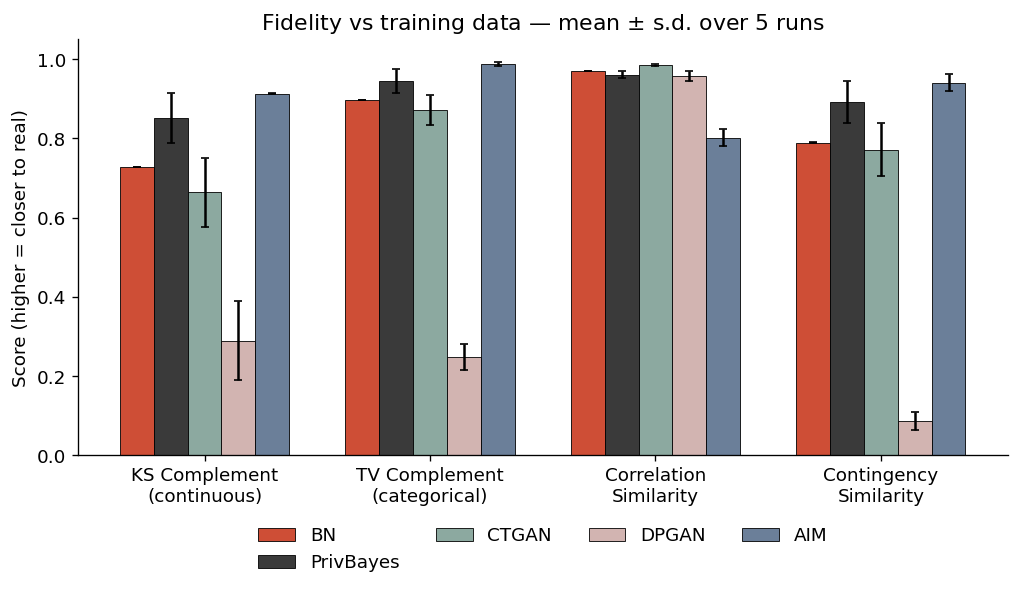

In [10]:
fidelity_metrics = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
fidelity_labels  = ['KS Complement\n(continuous)', 'TV Complement\n(categorical)',
                    'Correlation\nSimilarity', 'Contingency\nSimilarity']

x = np.arange(len(fidelity_metrics))
# 5 bars at width 0.15 span 0.75 of the unit x-step, leaving a 0.25 gap between
# metric groups. Within a group the centre spacing equals the bar width, so bars
# stay flush and the comparison that matters -- method against method on one
# metric -- reads as a single block.
width = 0.15
fig, ax = plt.subplots(figsize=(10, 4.5))

for i, method in enumerate(METHOD_ORDER):
    label = METHOD_LABELS[method]
    if label not in sdm.index or sdm.loc[label, fidelity_metrics].isna().all():
        continue                      # method not run yet (e.g. AIM, deferred)
    vals = [sdm.loc[label, m] for m in fidelity_metrics]
    errs = [sdm_sd.loc[label, m] for m in fidelity_metrics]
    off = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(x + off, vals, width, yerr=errs, capsize=2.5, label=label,
           color=COLORS[method], edgecolor='black', linewidth=0.5)

ax.set_xticks(x); ax.set_xticklabels(fidelity_labels)
ax.set_ylabel('Score (higher = closer to real)')
ax.set_ylim(0, 1.05)
ax.set_title('Fidelity vs training data — mean $\\pm$ s.d. over 5 runs')
ax.legend(frameon=False, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.32))
ax.spines[['top', 'right']].set_visible(False)
plt.savefig(RESULTS / 'fidelity_comparison.png', bbox_inches='tight', dpi=150)
plt.show()



## Plot 2 — Utility vs Privacy tradeoff

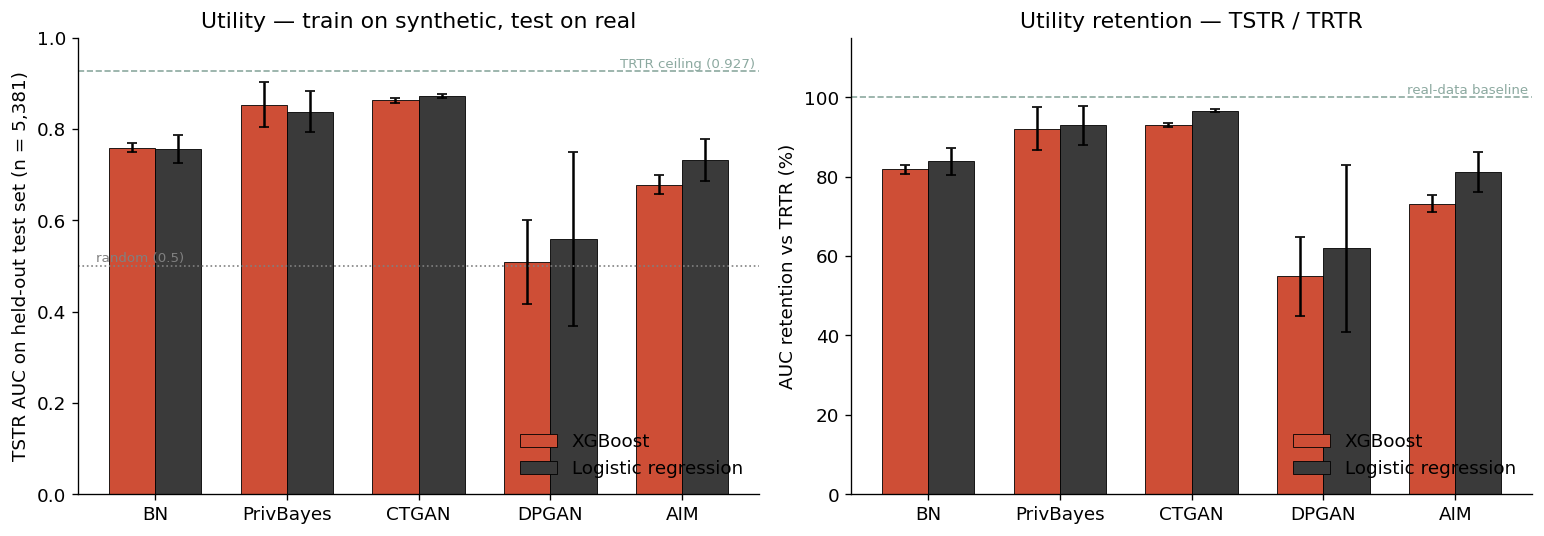

In [11]:
# Left: absolute TSTR AUC against the TRTR ceiling. Right: retention = TSTR/TRTR.
# Error bars are across-seed s.d. (seeds.RUN_SEEDS) - read them before comparing bars.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

labels = [METHOD_LABELS[m] for m in METHOD_ORDER
          if not util.loc[METHOD_LABELS[m]].isna().all()]
methods_present = [m for m in METHOD_ORDER if METHOD_LABELS[m] in labels]
x = np.arange(len(labels))
width = 0.35

# --- absolute AUC ---
ax = axes[0]
ax.bar(x - width/2, [util.loc[l, 'tstr_xgboost_auc'] for l in labels], width,
       yerr=[util_sd.loc[l, 'tstr_xgboost_auc'] for l in labels], capsize=3,
       label='XGBoost', color=ORANGE, edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, [util.loc[l, 'tstr_logistic_regression_auc'] for l in labels], width,
       yerr=[util_sd.loc[l, 'tstr_logistic_regression_auc'] for l in labels], capsize=3,
       label='Logistic regression', color=GREY, edgecolor='black', linewidth=0.5)

trtr = util['trtr_xgboost_auc'].dropna().iloc[0]
ax.axhline(trtr, ls='--', lw=1, color=TEAL)
ax.text(len(labels) - 0.45, trtr + 0.008, f'TRTR ceiling ({trtr:.3f})',
        fontsize=8, color=TEAL, ha='right')
ax.axhline(0.5, ls=':', lw=1, color='grey')
ax.text(-0.45, 0.51, 'random (0.5)', fontsize=8, color='grey')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('TSTR AUC on held-out test set (n = 5,381)')
ax.set_ylim(0, 1.0)
ax.set_title('Utility — train on synthetic, test on real')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

# --- retention ---
ax = axes[1]
ax.bar(x - width/2, [100 * util.loc[l, 'retention_xgboost'] for l in labels], width,
       yerr=[100 * util_sd.loc[l, 'retention_xgboost'] for l in labels], capsize=3,
       label='XGBoost', color=ORANGE, edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, [100 * util.loc[l, 'retention_logistic_regression'] for l in labels], width,
       yerr=[100 * util_sd.loc[l, 'retention_logistic_regression'] for l in labels], capsize=3,
       label='Logistic regression', color=GREY, edgecolor='black', linewidth=0.5)
ax.axhline(100, ls='--', lw=1, color=TEAL)
ax.text(len(labels) - 0.45, 101, 'real-data baseline', fontsize=8, color=TEAL, ha='right')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('AUC retention vs TRTR (%)')
ax.set_ylim(0, 115)
ax.set_title('Utility retention — TSTR / TRTR')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS / 'utility_metric_comparison.png', bbox_inches='tight', dpi=150)
plt.show()



### Plot 2b — utility vs privacy tradeoff: SUPERSEDED

This cell plotted in-house utility against **iteration-1** TAPAS `mia_auc`, which is
now in `results/tapas_LEGACY/` and is not going in the write-up.

The current version of this figure is
`benchmark_tapas/analysis/tradeoff.py` → `benchmark_tapas/results/figures/privacy_utility_tradeoff.png`:
5-attack mean membership advantage on the privacy axis, in-house TSTR with
across-seed error bars on the utility axis. Use that one.


## Neural convergence check — does `n_iter` need changing before the privacy audits?

`benchmark_tapas/` caps the GANs' `n_iter` during the TAPAS audits, because a single audit
re-fits the generator ~300 times. The cap is only defensible if the capped model has
**converged** — an undertrained GAN leaks less simply because it learned less, which reads
as privacy but isn't.

`benchmark_tapas/neural_tuning/convergence_check.py` sweeps `n_iter` over 3 seeds each at
50/100/200 plus 1 seed at `default` (2000 with early stopping) as the converged ceiling,
scoring with the same leak-free TSTR used above. Read the **plateau**, not the peak: pick the
smallest `n_iter` whose mean is within noise of the ceiling, where noise is the across-seed
s.d. in this very table.


In [12]:
CONV = Path('../benchmark_tapas/results/convergence/convergence_check_tstr.csv')
if not CONV.exists():
    print('convergence_check_tstr.csv not found - run benchmark_tapas/neural_tuning/convergence_check.py')
    conv = conv_summary = None
else:
    conv = pd.read_csv(CONV)
    conv['n_iter'] = conv['n_iter'].astype(str)
    ORDER = ['50', '100', '200', 'default']
    conv_summary = (conv.groupby(['method', 'n_iter'])
                        .agg(n_seeds=('seed', 'count'),
                             tstr_mean=('tstr_xgboost_auc', 'mean'),
                             tstr_sd=('tstr_xgboost_auc', 'std'),
                             retention_mean=('retention_xgboost', 'mean'),
                             fit_s=('fit_time_s', 'mean'),
                             gen_s=('generate_time_s', 'mean'))
                        .reset_index())
    conv_summary['_o'] = conv_summary['n_iter'].map({v: i for i, v in enumerate(ORDER)})
    conv_summary = conv_summary.sort_values(['method', '_o']).drop(columns='_o').reset_index(drop=True)
    display(conv_summary.round(4))



,method,n_iter,n_seeds,tstr_mean,tstr_sd,retention_mean,fit_s,gen_s
0,ctgan,50,3,0.8655,0.0043,0.9333,195.5900,0.1000
1,ctgan,100,3,0.8669,0.0064,0.9347,263.9533,0.0667
2,ctgan,200,3,0.8645,0.0057,0.9321,519.9400,0.0700
3,ctgan,default,1,0.8749,NaN,0.9434,1041.2000,0.0600
4,dpgan,50,3,0.4717,0.1033,0.5086,152.4900,0.1800
5,dpgan,100,3,0.4622,0.0532,0.4984,299.8167,0.1433
6,dpgan,200,3,0.4500,0.0246,0.4852,595.4033,0.1033
7,dpgan,default,1,0.6123,NaN,0.6602,1069.8100,0.0900


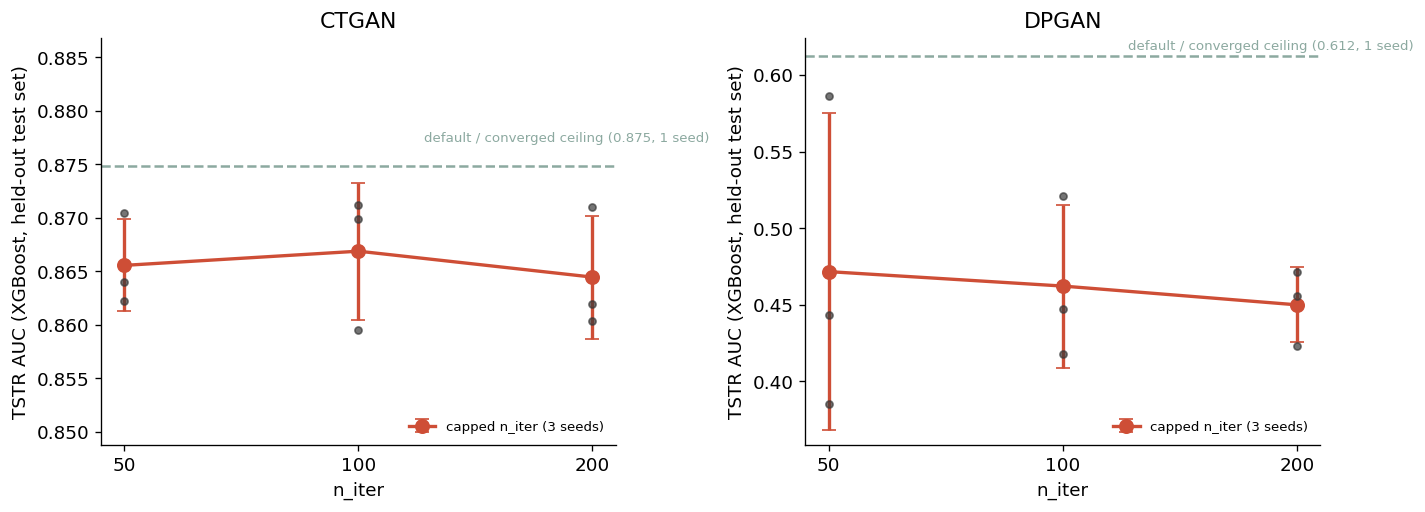

In [13]:
if conv is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=False)
    for ax, method in zip(axes, ['ctgan', 'dpgan']):
        s = conv_summary[conv_summary.method == method]
        caps = s[s.n_iter != 'default']
        ceil = s[s.n_iter == 'default']

        xs = np.arange(len(caps))
        ax.errorbar(xs, caps.tstr_mean, yerr=caps.tstr_sd, fmt='-o', color=ORANGE,
                    capsize=4, lw=2, ms=8, label='capped n_iter (3 seeds)')
        # individual draws, so the spread is visible rather than just summarised
        for xi, n in zip(xs, caps.n_iter):
            pts = conv[(conv.method == method) & (conv.n_iter == n)]['tstr_xgboost_auc']
            ax.scatter([xi] * len(pts), pts, color=GREY, s=18, zorder=3, alpha=0.7)

        if len(ceil):
            c = float(ceil.tstr_mean.iloc[0])
            ax.axhline(c, ls='--', lw=1.5, color=TEAL)
            # headroom above the ceiling so the label sits inside the axes
            lo = min(float((caps.tstr_mean - caps.tstr_sd.fillna(0)).min()), c)
            ax.set_ylim(lo - 0.01, c + 0.012)
            ax.text(len(caps) - 0.5, c + 0.002, f'default / converged ceiling ({c:.3f}, 1 seed)',
                    fontsize=8, color=TEAL, ha='right', va='bottom')

        ax.set_xticks(xs); ax.set_xticklabels(caps.n_iter)
        ax.set_xlabel('n_iter')
        ax.set_ylabel('TSTR AUC (XGBoost, held-out test set)')
        ax.set_title(METHOD_LABELS[method])
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(frameon=False, fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig(RESULTS / 'convergence_check.png', bbox_inches='tight', dpi=150)
    plt.show()





In [14]:
# Verdict: is each cap within noise of the CONVERGED ceiling?
#
# Two estimates of that ceiling exist, and they disagree for DPGAN:
#   (a) the convergence check's own `default` row  - 1 seed
#   (b) the main generation run in results/utility_summary.csv - 5 seeds, and it is the SAME
#       quantity, because sdg/generate_runs.py passes no n_iter and so uses the identical
#       plugin defaults (2000 cap, patience=5).
# (b) is the better estimate and is used as the ceiling here; (a) is shown for comparison.
#
# "Within noise" = gap to the ceiling <= the ceiling's own across-seed s.d. An undertrained
# generator leaks less because it learned less, so a privacy number measured on it is
# deflated - that is what this check exists to rule out.
CURRENT = {'ctgan': 50, 'dpgan': 100}      # what benchmark_tapas/config.py uses today

if conv is not None:
    for method in ['ctgan', 'dpgan']:
        s = conv_summary[conv_summary.method == method]
        label = METHOD_LABELS[method]
        ceil_5 = float(util.loc[label, 'tstr_xgboost_auc'])
        ceil_sd = float(util_sd.loc[label, 'tstr_xgboost_auc'])
        ceil_1 = float(s[s.n_iter == 'default'].tstr_mean.iloc[0]) if (s.n_iter == 'default').any() else np.nan

        print(f'\n{label}   ceiling = {ceil_5:.4f} +/- {ceil_sd:.4f}  (5 seeds, generation run)'
              f'   [convergence 1-seed draw: {ceil_1:.4f}]')
        print(f'   current cap in benchmark_tapas/config.py: n_iter={CURRENT[method]}')
        within = []
        for _, r in s[s.n_iter != 'default'].iterrows():
            gap = ceil_5 - r.tstr_mean
            ok = gap <= ceil_sd
            within.append(ok)
            print(f'     n_iter={r.n_iter:>3s}  TSTR={r.tstr_mean:.4f} +/- {r.tstr_sd:.4f}'
                  f'   gap {gap:+.4f}   {"within noise of ceiling" if ok else "BELOW ceiling"}')
        if any(within):
            first = s[s.n_iter != 'default'].iloc[int(np.argmax(within))]
            print(f'   -> converged from n_iter={first.n_iter}. Cap of {CURRENT[method]} is defensible.')
        else:
            print(f'   -> undertrained at every tested cap; privacy at n_iter={CURRENT[method]}'
                  f' would be measured on a weaker model than the one we report utility for.')




CTGAN   ceiling = 0.8626 +/- 0.0053  (5 seeds, generation run)   [convergence 1-seed draw: 0.8749]
   current cap in benchmark_tapas/config.py: n_iter=50
     n_iter= 50  TSTR=0.8655 +/- 0.0043   gap -0.0030   within noise of ceiling
     n_iter=100  TSTR=0.8669 +/- 0.0064   gap -0.0043   within noise of ceiling
     n_iter=200  TSTR=0.8645 +/- 0.0057   gap -0.0019   within noise of ceiling
   -> converged from n_iter=50. Cap of 50 is defensible.

DPGAN   ceiling = 0.5087 +/- 0.0921  (5 seeds, generation run)   [convergence 1-seed draw: 0.6123]
   current cap in benchmark_tapas/config.py: n_iter=100
     n_iter= 50  TSTR=0.4717 +/- 0.1033   gap +0.0371   within noise of ceiling
     n_iter=100  TSTR=0.4622 +/- 0.0532   gap +0.0465   within noise of ceiling
     n_iter=200  TSTR=0.4500 +/- 0.0246   gap +0.0587   within noise of ceiling
   -> converged from n_iter=50. Cap of 100 is defensible.


## Shadow-model counts — does a bigger sample fix the saturated epsilon bound?

Every generator in the 50/100 benchmark returned **`eps_low_95 = 2.209964`** — the same
value to six decimal places. Four identical numbers is not four measurements agreeing; it
is a **ceiling**. With 100 test samples the smallest resolvable false-positive rate is
1/100, so the 95% lower bound on `ln(TP/FP)` cannot rise past a fixed point no matter how
badly a generator leaks. The number was describing our sample size, not the generators.

The literature runs far larger — TAPAS's own Experiment 2 and Chida et al. both use
**1000 train / 2500 test**. `benchmark_tapas/scripts/run_pilot_counts.py` runs one
generator at those counts to test whether the bound actually moves before committing the
full budget.

Below: the pilot result, and the question it raises in turn — *is the new bound a
measurement, or just a higher ceiling?*


In [15]:
PILOT = Path('../benchmark_tapas/results/pilot_counts')
PER_METHOD = Path('../benchmark_tapas/results/per_method')

def load_pilot(method, num_train, num_test):
    """(pilot dataframe, baseline dataframe) for one method, or (None, None)."""
    f = PILOT / f'{method}_{num_train}_{num_test}' / f'pilot_{method}_{num_train}_{num_test}.csv'
    b = PER_METHOD / method / f'effeps_{method}.csv'
    return (pd.read_csv(f) if f.exists() else None,
            pd.read_csv(b) if b.exists() else None)

# Any pilot that has been run. DPGAN appears here automatically once its run lands.
pilots = sorted(d.name for d in PILOT.glob('*_*_*') if d.is_dir())
print('pilots available:', pilots if pilots else 'none')

BASE_TRAIN, BASE_TEST = 50, 100
rows = []
for d in pilots:
    method, ntr, nte = d.rsplit('_', 2)
    pilot, base = load_pilot(method, int(ntr), int(nte))
    if pilot is None:
        continue
    for src, counts, df in (('baseline', f'{BASE_TRAIN}/{BASE_TEST}', base),
                            ('pilot', f'{ntr}/{nte}', pilot)):
        if df is None:
            continue
        for _, r in df.iterrows():
            rows.append({'method': method, 'setting': src, 'counts': counts,
                         'fits': (BASE_TRAIN + BASE_TEST) if src == 'baseline' else int(ntr) + int(nte),
                         'attack': r['attack'].split('(')[0].strip(),
                         'auc': r['auc'], 'tp': r['tp'], 'fp': r['fp'],
                         'mia_advantage': r.get('mia_advantage', float('nan')),
                         'eps_low_95': r.get('eps_low_95', float('nan')),
                         'eps_high_95': r.get('eps_high_95', float('nan'))})
pilot_df = pd.DataFrame(rows)
display(pilot_df.round(4))



pilots available: none


""


In [16]:
# Two panels. Left: eps_low_95 is IDENTICAL across generators -> it is a property of the
# sample size, not the data. Right: which attacks actually succeed -> this DOES differ.
if not pilot_df.empty:
    methods = list(pilot_df['method'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

    # --- left: the bound, per generator, baseline vs pilot ---
    ax = axes[0]
    x = np.arange(len(methods)); width = 0.36
    for i, (setting, colour) in enumerate([('baseline', GREY), ('pilot', ORANGE)]):
        vals, lbl = [], setting
        for m in methods:
            sub = pilot_df[(pilot_df.method == m) & (pilot_df.setting == setting)]
            vals.append(sub.eps_low_95.max() if len(sub) else np.nan)
            if len(sub):
                lbl = f'{setting} ({sub.counts.iloc[0]})'
        ax.bar(x + (i - 0.5) * width, vals, width, label=lbl, color=colour,
               edgecolor='black', linewidth=0.5)
        for xi, v in zip(x + (i - 0.5) * width, vals):
            if not np.isnan(v):
                ax.text(xi, v + 0.12, f'{v:.2f}', ha='center', fontsize=8)
    ax.axhline(1.0, ls=':', lw=1.2, color=TEAL)
    ax.text(len(methods) - 0.5, 1.1, 'formal budget $\\varepsilon$ = 1.0',
            fontsize=8, color=TEAL, ha='right')
    ax.set_xticks(x); ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in methods])
    ax.set_ylabel('worst-case $\\varepsilon_{eff}$ lower bound (95%)')
    ax.set_ylim(0, 6.6)
    ax.set_title('The bound is identical across generators\n(it measures n, not leakage)')
    ax.legend(frameon=False, fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)

    # --- right: per-attack AUC at the pilot counts -> the real discriminator ---
    ax = axes[1]
    piv = (pilot_df[pilot_df.setting == 'pilot']
           .pivot_table(index='attack', columns='method', values='auc'))
    order = ['Groundhog', 'ShadowModelling', 'ProbabilityEstimation',
             'LocalNeighbourhood', 'ClosestDistance']
    piv = piv.reindex([o for o in order if o in piv.index])
    xa = np.arange(len(piv)); w = 0.8 / max(len(methods), 1)
    for i, m in enumerate(methods):
        if m not in piv.columns:
            continue
        bar_colour = [ORANGE, GREY, TEAL, SLATE][i % 4]
        ax.bar(xa + (i - (len(methods) - 1) / 2) * w, piv[m], w,
               label=METHOD_LABELS.get(m, m), color=bar_colour,
               edgecolor='black', linewidth=0.5)
    ax.axhline(0.5, ls='--', lw=1, color=TEAL)
    ax.text(-0.42, 0.52, 'random (0.5)', fontsize=8, color=TEAL, ha='left')
    ax.set_xticks(xa)
    ax.set_xticklabels(piv.index, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('attack AUC at 1000/2500')
    ax.set_ylim(0, 1.08)
    ax.set_title('Which attacks succeed DOES differ\n(more succeed against the DP method)')
    ax.legend(frameon=False, fontsize=8, loc='upper right',
              bbox_to_anchor=(1.0, 0.92))
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(RESULTS / 'pilot_counts.png', bbox_inches='tight', dpi=150)
    plt.show()



In [17]:
# Is the new bound a MEASUREMENT or a higher CEILING? FP decides.
#   FP > 0  -> ln(TP/FP) is finite, eps_high is finite: a real measurement.
#   FP = 0  -> the attack never erred; the bound is only "how small could FP be given n
#              samples", which grows without limit as n grows. Still a ceiling.
if not pilot_df.empty:
    for method in pilot_df['method'].unique():
        d = pilot_df[(pilot_df.method == method) & (pilot_df.setting == 'pilot')]
        b = pilot_df[(pilot_df.method == method) & (pilot_df.setting == 'baseline')]
        best = d.loc[d.eps_low_95.idxmax()]
        base_best = b.eps_low_95.max() if len(b) else float('nan')
        n_base, n_pilot = int(b.fits.iloc[0]) if len(b) else 150, int(d.fits.iloc[0])

        print(f'\n{METHOD_LABELS.get(method, method)}   {n_base} -> {n_pilot} fits')
        print(f'  eps_low_95:  {base_best:.4f}  ->  {best.eps_low_95:.4f}   '
              f'({best.eps_low_95 - base_best:+.4f})')
        print(f'  worst attack: {best.attack}   tp={best.tp:.3f}  fp={best.fp:.3f}  '
              f'eps_high_95={best.eps_high_95}')

        if best.fp == 0:
            pred = base_best + np.log(n_pilot / n_base)
            print(f'  FP is still ZERO -> this is a HIGHER CEILING, not a measurement.')
            print(f'  ln(n) prediction was {pred:.2f}, observed {best.eps_low_95:.2f}.')
            print(f'  The true leakage is >= {best.eps_low_95:.2f}, unbounded above '
                  f'(eps_high = inf).')
            for n in (8000, 20000):
                print(f'     at {n:,} fits the bound would be ~'
                      f'{base_best + np.log(n / n_base):.2f} - still a ceiling')
        else:
            print(f'  FP > 0 -> ln(TP/FP) is FINITE. This is a real measurement of leakage.')

        # how many attacks actually separate the two worlds
        sep = (d.auc == 1.0).sum()
        print(f'  {sep}/{len(d)} attacks fully separate D+ from D- '
              f'({(d.auc == 0.0).sum()} report AUC exactly 0.0 - see note below)')


**Reading this.** The bound moved a long way (2.21 → 5.55), which settles the original
question: at 50/100 it was sample-size limited, and the counts were the binding constraint.

But `fp = 0` and `eps_high_95 = inf` mean the attack still never made a mistake — 2500 out
of 2500 correct. So 5.55 is **a higher ceiling, not a measurement**: it says "leakage is at
least 5.55", with no upper limit, and it will keep climbing as `ln(n)` for as long as the
attack stays perfect. Each 4× in sample size buys roughly +1.4.

Two consequences worth stating plainly:

1. **As a headline result this is stronger, not weaker.** "Empirical ε ≥ 5.55 against a
   formal budget of ε = 1" is a 5.5× violation, versus 2.2× before. The bound being a
   ceiling does not weaken the claim — it means the true figure is worse.
2. **It only distinguishes generators if some of them stop separating.** If every method
   still has FP = 0 at these counts, all four land on the same higher ceiling. The DPGAN
   pilot tests exactly that: it is the DP method most likely to resist.

**Caveat on the zero-AUC attacks.** Three of the five attacks report `auc = 0.000`,
`tp = 0`, `fp = 0` — at both count settings. AUC of exactly zero is *perfect inverted
ranking*; no signal would be 0.5. Combined with never predicting "member", these look
sign-flipped or degenerate rather than successfully resisted, and they pull every
generator's `mean_advantage` down equally. Unresolved — flagged for investigation before
the full run.


In [18]:
# The bound cannot separate the generators. What can?
if not pilot_df.empty and len(pilot_df.method.unique()) > 1:
    d = pilot_df[pilot_df.setting == 'pilot']
    summary = []
    for m in d.method.unique():
        s = d[d.method == m]
        summary.append({
            'method': METHOD_LABELS.get(m, m),
            'worst eps_low_95': round(s.eps_low_95.max(), 4),
            'eps_high': 'inf' if (s.eps_high_95 == np.inf).any() else 'finite',
            'attacks AUC=1.0': int((s.auc == 1.0).sum()),
            'attacks succeeding': f'{int((s.auc == 1.0).sum())}/{len(s)}',
            'mean advantage': round(s.mia_advantage.mean(), 3)
                              if 'mia_advantage' in s else np.nan,
        })
    display(pd.DataFrame(summary).set_index('method'))

    bounds = d.groupby('method').eps_low_95.max()
    if bounds.nunique() == 1:
        print(f'Every generator returns eps_low_95 = {bounds.iloc[0]:.6f} - identical to six')
        print('decimals, with FP = 0 and eps_high = inf throughout. The bound is a function')
        print('of sample size alone, so it CANNOT distinguish DP from non-DP here. Raising')
        print('the counts further just raises every generator together.')
        print()
        print('The separation lives in attack BREADTH instead - and it runs against DP:')
        for _, r in pd.DataFrame(summary).iterrows():
            print(f"   {r['method']:12s} {r['attacks succeeding']} attacks succeed")


**The bound cannot answer the research question.** BN (non-DP) and DPGAN (DP, ε = 1.0)
both return `eps_low_95 = 5.546079` — identical to six decimals, with `FP = 0` and
`eps_high = inf` in both cases. At 50/100 they both returned 2.209964. The value depends
only on the number of test samples, so raising the counts moves every generator together
and separates nothing. A full four-generator run at 1000/2500 (~48 h) would produce four
identical numbers.

**What the counts did buy** is a stronger absolute claim: ε_eff ≥ 5.55 against a formal
budget of ε = 1.0, a 5.5× violation rather than 2.2×. Worth reporting, and honest, provided
it is stated as a lower bound that tracks sample size.

**Where the generators actually differ is attack breadth, and DP loses.** Three of five
attacks fully separate D⁺ from D⁻ for DPGAN, versus two of five for BN — the DP method is
successfully attacked by *more* attacks than the non-DP baseline. ProbabilityEstimation is
the difference: useless against BN (AUC 0.000), perfect against DPGAN (AUC 1.000).

A hypothesis worth testing: DPGAN's fidelity is severely degraded (KSComplement 0.31,
ContingencySimilarity 0.069), and a kernel-density attack may locate the target *because*
the output distribution has collapsed. If so, DP noise at ε = 1 is opening a new attack
surface rather than closing one.

**Implication for the design.** To turn ε_eff into a measurement rather than a bound, the
lever is the **threat model**, not the counts: the attacker currently has exact knowledge
of the 499-record background, so a single-record swap is trivially detectable and every
generator leaks completely. Weakening that assumption is the change that would let FP rise
above zero.

**Still unresolved:** `ClosestDistance` reports AUC exactly 0.000 for both generators.
LocalNeighbourhood gives 0.500 for DPGAN (genuine no-signal), so a blanket sign error is
ruled out — but an AUC of exactly zero is perfect inverted ranking and needs explaining.


In [19]:
cost_path = RESULTS / 'computational_cost.csv'
if not cost_path.exists():
    print('computational_cost.csv not found - run sdg/generate_runs.py and the eval scripts')
else:
    cost = pd.read_csv(cost_path)
    summary = (cost.groupby(['method', 'stage', 'device'], sort=False)
                   .agg(n=('seed', 'count'),
                        wall_s_mean=('wall_clock_s', 'mean'),
                        wall_s_sd=('wall_clock_s', 'std'),
                        peak_mb_mean=('peak_memory_mb', 'mean'))
                   .reset_index())
    display(summary.round(2))

    tot = cost.groupby('stage')['wall_clock_s'].sum()
    print('total wall clock by stage (all methods x 5 seeds):')
    for stage, s in tot.items():
        print(f'   {stage:11s} {s/60:7.1f} min')
    print(f'   {"TOTAL":11s} {tot.sum()/60:7.1f} min')

    print('\nDevice: statistical generators are CPU-only (no GPU path in the plugin);')
    print('neural ones use CUDA. Peak memory is Python-level only (tracemalloc) - it does')
    print('not see torch CUDA buffers, so it understates CTGAN/DPGAN. Wall clock is the')
    print('trustworthy cross-method column.')



,method,stage,device,n,wall_s_mean,wall_s_sd,peak_mb_mean
0,bayesian_network,generation,cpu,5,8.24,1.05,43.50
1,privbayes,generation,cpu,5,117.54,0.56,112.23
2,ctgan,generation,cuda,5,47.75,0.88,55.85
3,dpgan,generation,cuda,5,73.24,5.81,48.56
4,aim,generation,cpu,5,99.20,33.36,73.03
5,bayesian_network,fidelity,cpu,5,0.32,0.00,7.42
6,privbayes,fidelity,cpu,5,0.32,0.00,7.36
7,ctgan,fidelity,cpu,5,0.31,0.01,7.35
8,dpgan,fidelity,cpu,5,0.31,0.01,7.35
9,aim,fidelity,cpu,5,0.31,0.00,7.36


total wall clock by stage (all methods x 5 seeds):
   fidelity        0.1 min
   generation     28.8 min
   utility         0.3 min
   TOTAL          29.3 min

Device: statistical generators are CPU-only (no GPU path in the plugin);
neural ones use CUDA. Peak memory is Python-level only (tracemalloc) - it does
not see torch CUDA buffers, so it understates CTGAN/DPGAN. Wall clock is the
trustworthy cross-method column.


In [20]:
# Can we afford variance estimates (multiple seeds) on the TAPAS privacy side?
#
# ALL TIMES BELOW COME FROM THE GPU WORKSTATION. Two sources, both measured there:
#   PROBE_500  - benchmark_tapas/neural_tuning/probe_fit_time.py: mean of 5 real
#                fit+generate cycles on a 500-row TAPAS world (background+target),
#                at the n_iter the audit will actually use. This is the number that
#                matters, because TAPAS refits on 500 rows, not 21,523.
#   cost       - results/computational_cost.csv: measured generation on the full
#                21,523 rows. Used only for the n_iter=2000 rows, which we are NOT
#                probing. Those are an UPPER BOUND on the audit cost, since the fit
#                is 43x the rows - shown to justify capping, not to plan against.
# fits = num_train + num_test, NOT x2. num_train already counts synthetic datasets
# (one generator fit each); the labeller halves it into pairs and emits both the
# member and non-member world, returning num_samples datasets. Verified against the
# completed 50/100 audit: its cached threat model memoised exactly 50 training and
# 100 testing datasets.
FITS = 50 + 100           # = 150 fit+generate cycles (75 D+/D- pairs)

# Paste the "PASTE INTO analysis.ipynb" lines from probe_fit_time.py here.
# Run:  python benchmark_tapas/neural_tuning/probe_fit_time.py bayesian_network privbayes ctgan dpgan
# Measured on the GPU workstation, 2026-08-16: mean of 5 fit+generate cycles on a
# real 500-row TAPAS world, at the n_iter each method will actually be audited with
# (GANs capped at 50; BN/PrivBayes have no n_iter).
PROBE_500 = {
    'bayesian_network':  1.05,
    'privbayes':        23.03,
    'ctgan':             1.44,
    'dpgan':             2.24,
}

def audit_hours(s_per_fit, seeds=1):
    return FITS * s_per_fit * seeds / 3600

missing = [m for m, v in PROBE_500.items() if v is None]
if missing:
    print('Probe numbers not filled in yet for:', ', '.join(missing))
    print('Run on the workstation, then paste the printed lines into PROBE_500 above:')
    print('   python benchmark_tapas/neural_tuning/probe_fit_time.py '
          'bayesian_network privbayes ctgan dpgan')
    print()

# --- neural methods: capped n_iter=50 (probe) vs the 2000-epoch default (upper bound) ---
cost = pd.read_csv(RESULTS / 'computational_cost.csv')
gen_full = (cost[cost.stage == 'generation']
            .groupby('method')['wall_clock_s'].mean())      # workstation, 21,523 rows, default n_iter

rows = []
for m in ['ctgan', 'dpgan']:
    if PROBE_500[m] is not None:
        rows.append({'method': METHOD_LABELS[m], 'n_iter': '50 (probe, 500 rows)',
                     's/fit': round(PROBE_500[m], 2),
                     '1 seed (h)': round(audit_hours(PROBE_500[m], 1), 2),
                     '3 seeds (h)': round(audit_hours(PROBE_500[m], 3), 2),
                     '5 seeds (h)': round(audit_hours(PROBE_500[m], 5), 2)})
    f = float(gen_full[m])
    rows.append({'method': METHOD_LABELS[m], 'n_iter': '2000 (full-data, upper bound)',
                 's/fit': round(f, 1),
                 '1 seed (h)': round(audit_hours(f, 1), 1),
                 '3 seeds (h)': round(audit_hours(f, 3), 1),
                 '5 seeds (h)': round(audit_hours(f, 5), 1)})
display(pd.DataFrame(rows).set_index(['method', 'n_iter']))




s/fit  1 seed (h)  3 seeds (h)  \
method n_iter                                                          
CTGAN  50 (probe, 500 rows)            1.44        0.06         0.18   
       2000 (full-data, upper bound)  47.80        2.00         6.00   
DPGAN  50 (probe, 500 rows)            2.24        0.09         0.28   
       2000 (full-data, upper bound)  73.20        3.10         9.20   

                                      5 seeds (h)  
method n_iter                                      
CTGAN  50 (probe, 500 rows)                  0.30  
       2000 (full-data, upper bound)         9.90  
DPGAN  50 (probe, 500 rows)                  0.47  
       2000 (full-data, upper bound)        15.30

## Privacy-audit cost for the statistical generators

Same arithmetic, for BN and PrivBayes. They have no `n_iter`, so there is only one
configuration to audit. Numbers come from the same workstation probe, so they are
directly comparable to the neural table above.


In [21]:
# BN and PrivBayes: no n_iter, so a single configuration each.
rows = []
for m in ['bayesian_network', 'privbayes']:
    s = PROBE_500[m]
    if s is None:
        continue
    rows.append({'method': METHOD_LABELS[m], 's/fit (500 rows)': round(s, 2),
                 '1 seed (h)': round(audit_hours(s, 1), 2),
                 '3 seeds (h)': round(audit_hours(s, 3), 2),
                 '5 seeds (h)': round(audit_hours(s, 5), 2)})
if rows:
    stat = pd.DataFrame(rows).set_index('method')
    display(stat)

    have = [m for m in PROBE_500 if PROBE_500[m] is not None]
    if len(have) == 4:
        for seeds in (1, 3, 5):
            total = sum(audit_hours(PROBE_500[m], seeds) for m in have)
            print(f'all four generators, {seeds} seed(s): {total:6.2f} h')
else:
    print('Fill in PROBE_500 in the cell above first.')


,s/fit (500 rows),1 seed (h),3 seeds (h),5 seeds (h)
method,,,,
BN,1.05,0.04,0.13,0.22
PrivBayes,23.03,0.96,2.88,4.80


all four generators, 1 seed(s):   1.16 h
all four generators, 3 seed(s):   3.47 h
all four generators, 5 seed(s):   5.78 h


### Where the privacy budget goes: counts, not seeds

Utility and fidelity above run over 5 seeds. **Privacy stays single-seed**, deliberately.

At `num_train=50 / num_test=100` every generator returned `eps_low_95 = 2.209964` —
identical to six decimals. That is a **sample-size ceiling**, not four agreeing
measurements: with 100 test samples the smallest resolvable false-positive rate is
1/100, so the bound cannot rise however much a generator leaks.

More seeds would put error bars on a number that is measuring our sample size. Raising
the counts is what addresses it. Using the per-fit times measured above
(`fits = num_train + num_test`):

| | all four, 1 seed | all four, 3 seeds |
|---|---|---|
| 50 / 100 (current) | 1.2 h | 3.5 h |
| 1000 / 2500 (TAPAS Exp 2, Chida et al.) | **27 h** | 81 h |

So it is an either/or, and the bound comes first. `benchmark_tapas/scripts/run_pilot_counts.py`
runs BN alone at 1000/2500 (~1 h) to check the bound actually moves before committing
the 27 h. Multi-seed privacy is deferred to future work.


## AIM bin-count tuning

**Question:** at ε = 1.0, does bin count determine whether AIM ever buys a numerical × numerical marginal — and where does utility peak?

AIM needs an all-discrete domain, so the 5 continuous columns are binned before fitting and decoded after. Bin count is AIM's one free preprocessing parameter. Ganev et al. (ACM CCS 2025, [arXiv:2504.06923](https://arxiv.org/abs/2504.06923)) report an **inverted-U** in utility vs bin count (p2, Fig. 1) and note that AIM's own implementation uses **uniform with 32 bins, domain provided** (p11).

**Method** — `sdg/aim_tuning/aim_tuning.py`. Bin count is the only variable; ε=1.0, δ=1e-9, degree=2, `max_cells=10000`, 208 rounds and public-codebook bounds are all pinned. Sweep: 5, 10, 20, 25, 32, 50, 100 (250 dropped — a numerical pair would be 62,500 cells, above the default `max_cells=10000`, so it would be excluded from the candidate workload before selection). Per setting we record the selected marginals, fidelity, TSTR utility, the discretisation ceiling, and runtime.

**Selection:** peak utility → 3 repeat runs at that setting → measure the error margin → smallest setting inside it.

**Outcome — b = 32.** Numerical pairs *are* bought, but only at b ≤ 10, and they bring no measurable benefit. Repeats at b=32 span 0.710–0.800, so the whole utility curve is inside the noise and cannot pick a winner. b=32 topped the sweep *and* is the documented reference default, so both arguments agree.

In [22]:
TUNING = Path('../sdg/aim_tuning')
tune = pd.read_csv(TUNING / 'aim_tuning_results.csv').sort_values('bins').reset_index(drop=True)
reps = pd.read_csv(TUNING / 'aim_tuning_repeats.csv')

# Run-to-run wobble, measured at the peak setting. The sweep's own run at that
# setting is a 4th independent draw, so pool it with the 3 repeats.
peak_b = int(tune.loc[tune['xgb_syn_id'].idxmax(), 'bins'])
draws = pd.concat([reps['xgb_syn_id'], tune.loc[tune['bins'] == peak_b, 'xgb_syn_id']])
WOBBLE = draws.max() - draws.min()
print(f'peak bin = {peak_b} | {len(draws)} draws at b={peak_b}: '
      f'{sorted(round(v, 4) for v in draws)} | range = {WOBBLE:.4f}')

show = ['bins', 'n_numeric_pairs', 'xgb_syn_id', 'linear_syn_id', 'CorrelationSimilarity',
        'ceiling_CorrelationSimilarity', 'KSComplement', 'ceiling_KSComplement',
        'TVComplement', 'ContingencySimilarity', 'fit_secs']
tune[show].round(4)


peak bin = 32 | 4 draws at b=32: [0.7103, 0.7773, 0.7948, 0.8] | range = 0.0896


,bins,n_numeric_pairs,xgb_syn_id,linear_syn_id,CorrelationSimilarity,ceiling_CorrelationSimilarity,KSComplement,ceiling_KSComplement,TVComplement,ContingencySimilarity,fit_secs
0,5,2,0.7605,0.7488,0.9038,0.9927,0.8456,0.8443,0.9847,0.9352,223.2
1,10,2,0.6738,0.6647,0.8874,0.9980,0.8922,0.8907,0.9828,0.9261,189.0
2,20,0,0.6587,0.5947,0.8148,0.9984,0.9116,0.9140,0.9858,0.9089,152.8
3,25,0,0.7844,0.7100,0.9099,0.9980,0.9199,0.9193,0.9929,0.9545,108.8
4,32,0,0.8000,0.7800,0.8992,0.9994,0.9402,0.9379,0.9938,0.9626,140.4
5,50,0,0.7660,0.7415,0.8551,0.9993,0.9306,0.9311,0.9944,0.9557,144.8
6,100,0,0.7923,0.7798,0.8409,0.9997,0.9556,0.9565,0.9930,0.9488,118.5


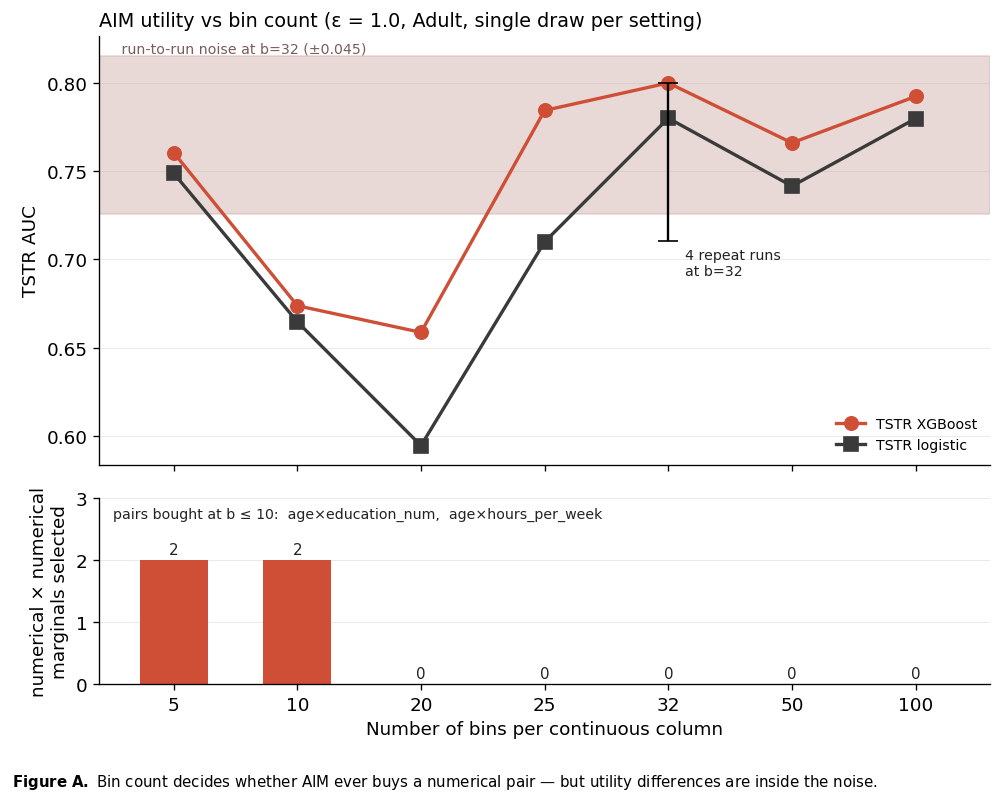

In [23]:
# Figure A — utility vs bin count, with the measured noise band, over the pair-count diagnostic.
# Two panels rather than a twin axis: AUC and a raw count are different scales.
x = np.arange(len(tune))
xi = int(tune.index[tune['bins'] == peak_b][0])
peak_mean = draws.mean()

fig, axes = plt.subplots(2, 1, figsize=(8.4, 6.8), sharex=True,
                         gridspec_kw={'height_ratios': [2.3, 1]})

ax = axes[0]
ax.axhspan(peak_mean - WOBBLE / 2, peak_mean + WOBBLE / 2, color=PINK, alpha=0.5, zorder=0)
ax.text(0.02, peak_mean + WOBBLE / 2, f' run-to-run noise at b={peak_b} (±{WOBBLE/2:.3f})',
        transform=ax.get_yaxis_transform(), ha='left', va='bottom', fontsize=8.5, color='#7a5c5a')
ax.plot(x, tune['xgb_syn_id'], '-o', color=ORANGE, lw=2, ms=8, zorder=3, label='TSTR XGBoost')
ax.plot(x, tune['linear_syn_id'], '-s', color=GREY, lw=2, ms=8, zorder=3, label='TSTR logistic')
ax.errorbar(xi, peak_mean, yerr=[[peak_mean - draws.min()], [draws.max() - peak_mean]],
            fmt='none', ecolor='black', capsize=6, elinewidth=1.4, zorder=4)
ax.annotate(f'{len(draws)} repeat runs\nat b={peak_b}', (xi, draws.min()),
            textcoords='offset points', xytext=(10, -4), fontsize=8.5, va='top', color='#222222')
ax.set_ylabel('TSTR AUC')
ax.set_title('AIM utility vs bin count (ε = 1.0, Adult, single draw per setting)',
             fontsize=11.5, loc='left')
ax.legend(fontsize=8.5, frameon=False, loc='lower right')

ax = axes[1]
ax.bar(x, tune['n_numeric_pairs'], color=ORANGE, width=0.55)
for xj, v in zip(x, tune['n_numeric_pairs']):
    ax.text(xj, v + 0.05, str(int(v)), ha='center', va='bottom', fontsize=9, color='#222222')
ax.set_ylim(0, max(2.6, tune['n_numeric_pairs'].max() * 1.5))
ax.set_ylabel('numerical × numerical\nmarginals selected')
ax.set_xlabel('Number of bins per continuous column')
ax.set_xticks(x)
ax.set_xticklabels(tune['bins'].astype(int))
ax.text(0.015, 0.95, 'pairs bought at b ≤ 10:  age×education_num,  age×hours_per_week',
        transform=ax.transAxes, va='top', ha='left', fontsize=8.5, color='#222222')

for a in axes:
    a.grid(axis='y', lw=0.5, alpha=0.3)
    a.set_axisbelow(True)
    for s in ('top', 'right'):
        a.spines[s].set_visible(False)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.01, 0.02,
         r"$\bf{Figure\ A.}$ Bin count decides whether AIM ever buys a numerical pair — "
         "but utility differences are inside the noise.",
         ha='left', va='bottom', fontsize=9)
plt.savefig(TUNING / 'aim_tuning_utility.png', bbox_inches='tight')
plt.show()


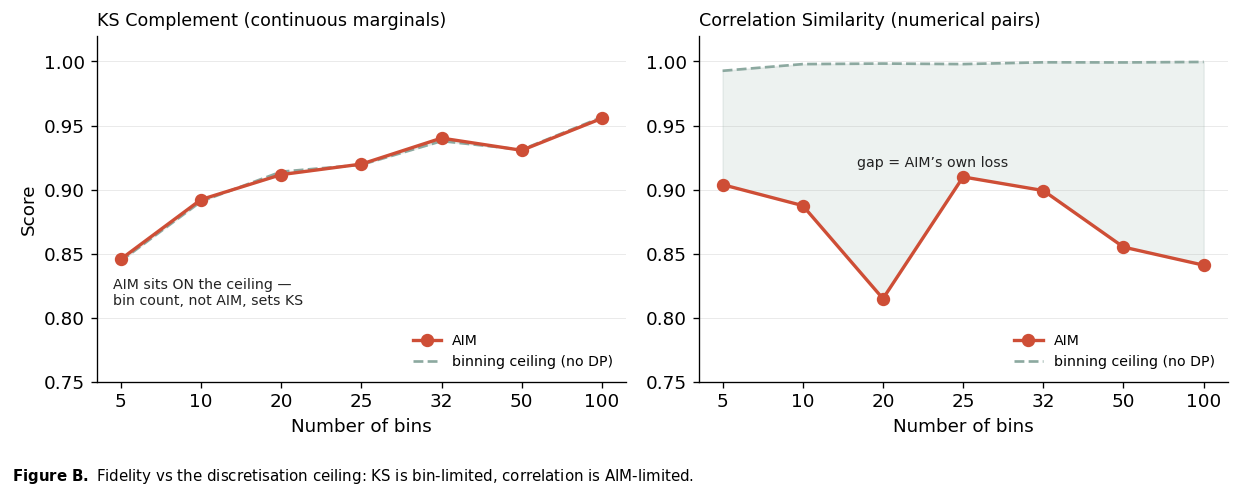

In [24]:
# Figure B — fidelity against the discretisation ceiling.
# Ceiling = real data pushed through encode->decode with AIM removed, i.e. the best
# score achievable at that bin count. The shaded gap is AIM's own loss.
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2), sharex=True)

for ax, metric, title in [
    (axes[0], 'KSComplement', 'KS Complement (continuous marginals)'),
    (axes[1], 'CorrelationSimilarity', 'Correlation Similarity (numerical pairs)'),
]:
    ax.plot(x, tune[metric], '-o', color=ORANGE, lw=2, ms=7, label='AIM', zorder=3)
    ax.plot(x, tune[f'ceiling_{metric}'], '--', color=TEAL, lw=1.6,
            label='binning ceiling (no DP)', zorder=2)
    ax.fill_between(x, tune[metric], tune[f'ceiling_{metric}'], color=TEAL, alpha=0.15, zorder=1)
    ax.set_title(title, fontsize=10.5, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(tune['bins'].astype(int))
    ax.set_xlabel('Number of bins')
    ax.set_ylim(0.75, 1.02)
    ax.grid(axis='y', lw=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.legend(fontsize=8.5, frameon=False, loc='lower right')

axes[0].set_ylabel('Score')
axes[0].text(0.03, 0.30, 'AIM sits ON the ceiling —\nbin count, not AIM, sets KS',
             transform=axes[0].transAxes, fontsize=8.5, color='#222222', va='top')
axes[1].text(0.30, 0.62, 'gap = AIM’s own loss', transform=axes[1].transAxes,
             fontsize=8.5, color='#222222')

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.01, 0.02,
         r"$\bf{Figure\ B.}$ Fidelity vs the discretisation ceiling: KS is bin-limited, "
         "correlation is AIM-limited.",
         ha='left', va='bottom', fontsize=9)
plt.savefig(TUNING / 'aim_tuning_fidelity.png', bbox_inches='tight')
plt.show()


## AIM at the chosen bin count (b = 32)

The AIM row in `results/*.csv` is still the **b = 20** run (SmartNoise's default), which is what
motivated the sweep. The chosen setting is **b = 32** — the AIM paper's own preprocessing
(McKenna et al. 2022, Appendix A: *"We discretize each numerical attribute into 32 equal-width
bins, using the min/max values from the domain file"*), and the top of our sweep.

Its metrics come from the tuning harness, which calls the same SDMetrics and Synthcity functions:
`aim_tuning_results.csv` (the sweep run) plus `aim_tuning_repeats.csv` (3 repeats) — 4 draws in
total, so AIM is plotted as the **mean with min–max whiskers** while the other four remain single
runs. Nothing below is hardcoded.

Once `sdg/aim.py` is regenerated at b = 32 and both eval scripts rerun, `results/*.csv` becomes
authoritative and this section can just read from there.

In [25]:
# Assemble AIM's chosen-bin row from the tuning CSVs.
# FIDELITY ONLY. The tuning CSVs' utility columns (xgb_syn_id, linear_syn_id) come
# from synthcity's leaky Metrics.evaluate and are NOT comparable to the leak-free
# TSTR in results/utility_summary.csv, so they are deliberately not merged here.
# See the KNOWN ISSUE header in sdg/aim_tuning/aim_tuning.py.
CHOSEN_BINS = 32
TUNING = Path('../sdg/aim_tuning')

tune = pd.read_csv(TUNING / 'aim_tuning_results.csv')
reps = pd.read_csv(TUNING / 'aim_tuning_repeats.csv')
aim_draws = pd.concat([tune[tune['bins'] == CHOSEN_BINS], reps[reps['bins'] == CHOSEN_BINS]],
                      ignore_index=True)

FID_COLS = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
aim32_mean = aim_draws[FID_COLS].mean()
aim32_min  = aim_draws[FID_COLS].min()
aim32_max  = aim_draws[FID_COLS].max()

# copy with AIM's b=20 row swapped for the b=32 mean; the original is left untouched
sdm32 = sdm.copy()
for m in FID_COLS:
    sdm32.loc['AIM', m] = aim32_mean[m]

print(f'AIM b={CHOSEN_BINS}: {len(aim_draws)} draws (fidelity only)')
delta = pd.DataFrame({
    'b=20 (multi-run mean)': [sdm.loc['AIM', c] for c in FID_COLS],
    f'b={CHOSEN_BINS} (mean of {len(aim_draws)})': [aim32_mean[c] for c in FID_COLS],
}, index=FID_COLS)
delta['delta'] = delta.iloc[:, 1] - delta.iloc[:, 0]
delta.round(4)



AIM b=32: 4 draws (fidelity only)


,b=20 (multi-run mean),b=32 (mean of 4),delta
KSComplement,0.9121,0.9380,0.0259
TVComplement,0.9876,0.9923,0.0047
CorrelationSimilarity,0.8018,0.8909,0.0892
ContingencySimilarity,0.9402,0.9531,0.0129


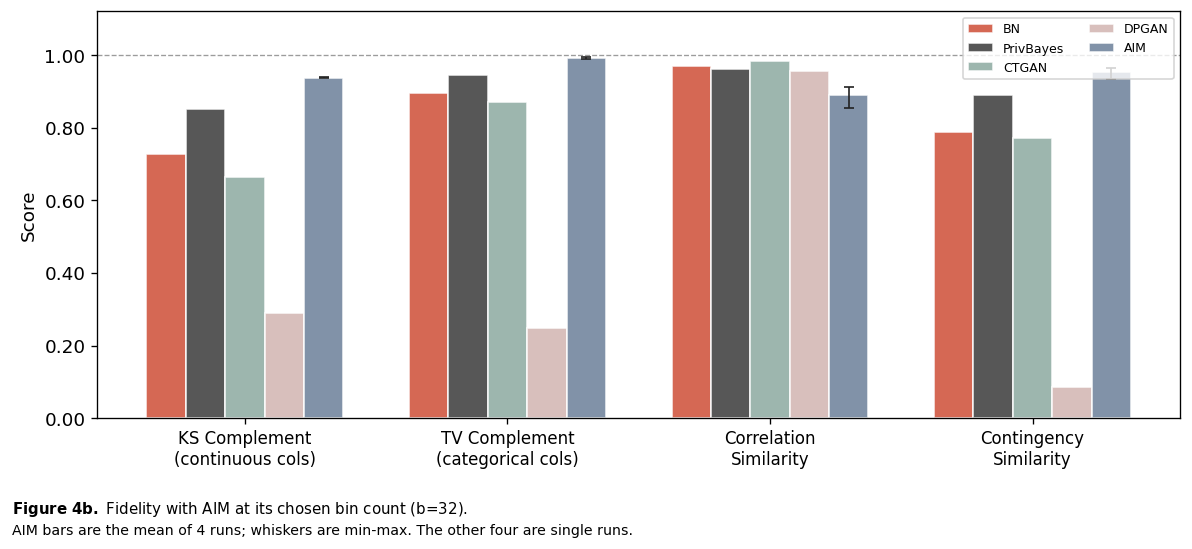

In [26]:
# Fidelity with AIM at its chosen bin count. AIM carries min-max whiskers over its 4 draws;
# the other four generators are single runs and have none.
fid = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
fid_labels = ['KS Complement\n(continuous cols)', 'TV Complement\n(categorical cols)',
              'Correlation\nSimilarity', 'Contingency\nSimilarity']

x = np.arange(len(fid)); width = 0.15
fig, ax = plt.subplots(figsize=(10, 4.6))
for i, m in enumerate(METHOD_ORDER):
    lab = METHOD_LABELS[m]
    off = x + (i - (len(METHOD_ORDER) - 1) / 2) * width
    vals = [sdm32.loc[lab, c] for c in fid]
    yerr = None
    if m == 'aim':
        yerr = np.array([[vals[j] - aim32_min[c] for j, c in enumerate(fid)],
                         [aim32_max[c] - vals[j] for j, c in enumerate(fid)]])
    ax.bar(off, vals, width, label=lab, color=COLORS[m], alpha=0.85, edgecolor='white',
           yerr=yerr, capsize=3, error_kw={'elinewidth': 1, 'ecolor': '#222222'})

ax.set_xticks(x); ax.set_xticklabels(fid_labels, fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.12)
ax.axhline(1.0, color=GREY, ls='--', lw=0.8, alpha=0.5)
ax.legend(loc='upper right', fontsize=7.5, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout(rect=[0, 0.1, 1, 1])
fig.text(0.01, 0.045, r"$\bf{Figure\ 4b.}$ Fidelity with AIM at its chosen bin count "
                      f"(b={CHOSEN_BINS}).", ha='left', va='bottom', fontsize=9)
fig.text(0.01, 0.012, f"AIM bars are the mean of {len(aim_draws)} runs; whiskers are min-max. "
                      "The other four are single runs.", ha='left', va='bottom', fontsize=8.5)
plt.savefig(RESULTS / 'fidelity_comparison_b32.png', bbox_inches='tight')
plt.show()


### AIM b=32 utility comparison: SUPERSEDED pending the aim_tuning fix

This cell produced `results/utility_comparison_b32.png`, which has been deleted.

`sdg/aim_tuning/aim_tuning.py` still scores utility with synthcity's leaky
`Metrics.evaluate`, so its `xgb_syn_id` / `linear_syn_id` columns are not comparable
to the leak-free TSTR in `results/utility_summary.csv` — plotting them on one axis
would be misleading. See the KNOWN ISSUE header in that script; the fix is to swap in
`compute_tstr` from `evaluation/eval_utility.py` and re-run the sweep.

AIM's **fidelity** at b=32 is unaffected and is still plotted in the cell above.
